In [147]:
import sys
import os
sys.path.append(os.path.abspath('..'))

# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random


# Machine learning libraries  
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities


# Visualization and 
import altair as alt                        # Interactive visualization library

# data sources
import binance                              # Binance market data utilities

In [148]:
research.set_seed(42)

In [149]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [150]:
# Trading pair symbol
sym = 'BTCUSDT'
# time horizon of time series (time interval)
time_interval = '12h'
# Max number of auto-regressive lags
max_lags = 4
# Forecast horizon in steps 
forecast_horizon = 1
# Sharpe annualized rate (so it's independent of time frequency)
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)

In [151]:
import binance
print(binance.__file__)
print([x for x in dir(binance) if "download" in x.lower()])

c:\Users\micha\Documents\Code\school\cpp\classes\spring-2026\mat_4860\quant_trading_strategy\ML-Systematic-Trading-Engine\binance.py
['download_and_unzip', 'download_date_range', 'download_ohlc_timeseries', 'download_timeseries', 'download_trades']


In [152]:
# Data is already downloaded and processed into 12h OHLC CSV
# binance.download_date_range(sym, start_date, end_date)


In [153]:
ts = pl.read_csv(f"../historical_data/{sym}_{time_interval}_ohlc_updated.csv", try_parse_dates=True).sort('datetime')
ts


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,93986.0
2025-05-05 12:00:00,93986.1,95165.1,93559.6,94696.7
2025-05-06 00:00:00,94696.7,94893.3,93662.2,93770.3
2025-05-06 12:00:00,93770.3,96879.5,93327.0,96798.9
2025-05-07 00:00:00,96798.9,97700.0,96153.2,97000.0
…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1


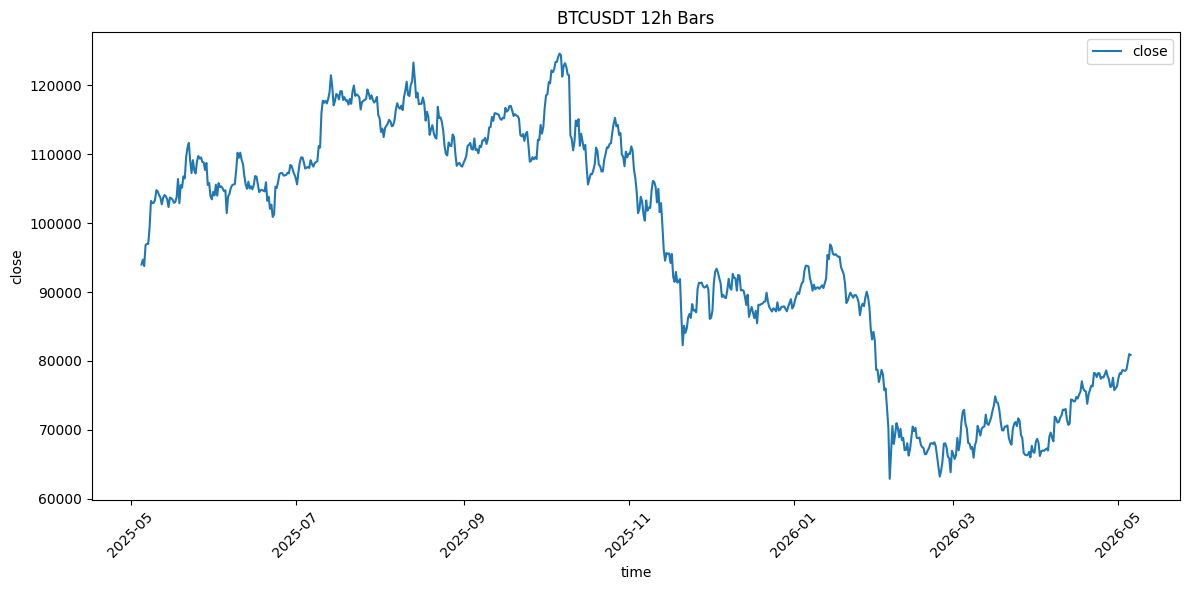

In [154]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [155]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)

alt.Chart(...)

### Feature Engineering

In [156]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [157]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create target and lagged features

In [158]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,close_log_return
datetime[μs],f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,93986.0,null
2025-05-05 12:00:00,93986.1,95165.1,93559.6,94696.7,0.007533
2025-05-06 00:00:00,94696.7,94893.3,93662.2,93770.3,-0.009831
2025-05-06 12:00:00,93770.3,96879.5,93327.0,96798.9,0.031787
2025-05-07 00:00:00,96798.9,97700.0,96153.2,97000.0,0.002075
…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528


In [159]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,93986.0,null,null,null,null,null
2025-05-05 12:00:00,93986.1,95165.1,93559.6,94696.7,0.007533,null,null,null,null
2025-05-06 00:00:00,94696.7,94893.3,93662.2,93770.3,-0.009831,0.007533,null,null,null
2025-05-06 12:00:00,93770.3,96879.5,93327.0,96798.9,0.031787,-0.009831,0.007533,null,null
2025-05-07 00:00:00,96798.9,97700.0,96153.2,97000.0,0.002075,0.031787,-0.009831,0.007533,null
…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,0.009799
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.001104
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,0.006981


In [160]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,93986.0,null,null,null,null,null
2025-05-05 12:00:00,93986.1,95165.1,93559.6,94696.7,0.007533,null,null,null,null
2025-05-06 00:00:00,94696.7,94893.3,93662.2,93770.3,-0.009831,0.007533,null,null,null
2025-05-06 12:00:00,93770.3,96879.5,93327.0,96798.9,0.031787,-0.009831,0.007533,null,null
2025-05-07 00:00:00,96798.9,97700.0,96153.2,97000.0,0.002075,0.031787,-0.009831,0.007533,null
…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,0.009799
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.001104
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,0.006981


In [161]:
ts = ts.drop_nulls()

In [162]:
research.plot_distribution(ts, target, no_bins = 100)

alt.Chart(...)

In [163]:
research.plot_distribution(ts, 'close', no_bins = 100)

alt.Chart(...)

### Build Model

In [164]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [165]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model, "Linear Model")
research.total_model_params(linear_model)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

### Split by time

In [166]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

In [167]:
len(ts)

727

In [168]:
int(len(ts) * test_size)

181

In [169]:
split_idx = int(len(ts) * (1-test_size))
split_idx

545

In [170]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]

In [171]:
ts_train

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-07 12:00:00,97000.0,97446.8,95718.5,96988.4,-0.00012,0.002075,0.031787,-0.009831,0.007533
2025-05-08 00:00:00,96988.4,99863.3,96831.5,99369.8,0.024257,-0.00012,0.002075,0.031787,-0.009831
2025-05-08 12:00:00,99369.9,104305.3,99050.1,103228.1,0.038093,0.024257,-0.00012,0.002075,0.031787
2025-05-09 00:00:00,103228.0,104373.0,102327.9,102914.5,-0.003043,0.038093,0.024257,-0.00012,0.002075
2025-05-09 12:00:00,102914.5,103746.8,102240.0,102941.9,0.000266,-0.003043,0.038093,0.024257,-0.00012
…,…,…,…,…,…,…,…,…,…
2026-02-01 12:00:00,78712.1,78732.0,75644.0,76931.5,-0.022881,0.000067,-0.052909,-0.014692,0.013228
2026-02-02 00:00:00,76931.6,78111.0,74555.0,77716.1,0.010147,-0.022881,0.000067,-0.052909,-0.014692
2026-02-02 12:00:00,77716.0,79311.0,77515.6,78692.5,0.012485,0.010147,-0.022881,0.000067,-0.052909


In [172]:
ts_test

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-04 00:00:00,75732.4,76952.5,75420.0,75987.6,0.003364,-0.030017,-0.008325,0.012485,0.010147
2026-02-04 12:00:00,75987.6,76245.5,71838.0,73137.4,-0.03823,0.003364,-0.030017,-0.008325,0.012485
2026-02-05 00:00:00,73137.5,73316.3,69862.0,70279.0,-0.039867,-0.03823,0.003364,-0.030017,-0.008325
2026-02-05 12:00:00,70279.1,70848.6,62233.3,62868.1,-0.111434,-0.039867,-0.03823,0.003364,-0.030017
2026-02-06 00:00:00,62868.1,66783.0,59800.0,66586.1,0.057457,-0.111434,-0.039867,-0.03823,0.003364
…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,0.009799
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.001104
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,0.006981


In [173]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)


In [174]:
X_train

tensor([[ 2.0753e-03],
        [-1.1959e-04],
        [ 2.4257e-02],
        [ 3.8093e-02],
        [-3.0426e-03],
        [ 2.6620e-04],
        [ 4.1945e-03],
        [ 1.3588e-02],
        [-1.6724e-03],
        [-5.1848e-03],
        [-3.5384e-03],
        [-9.3566e-03],
        [ 9.1676e-03],
        [ 3.8168e-03],
        [-1.7174e-03],
        [-4.2949e-03],
        [-1.0912e-02],
        [ 1.3387e-02],
        [-9.6465e-04],
        [-1.9543e-03],
        [-4.5358e-03],
        [ 1.3144e-03],
        [ 6.6658e-03],
        [ 2.5110e-02],
        [-3.3403e-02],
        [ 2.5136e-02],
        [-3.5350e-03],
        [ 1.5483e-02],
        [-2.8993e-03],
        [ 2.8865e-02],
        [ 1.2102e-02],
        [ 6.4562e-03],
        [-2.3830e-02],
        [-1.6289e-02],
        [ 1.7380e-02],
        [-1.3404e-02],
        [-4.5125e-03],
        [ 1.6116e-02],
        [ 7.1406e-03],
        [-3.1936e-03],
        [ 1.4160e-03],
        [-5.9744e-03],
        [-6.2376e-04],
        [-1

In [175]:
X_train.shape

torch.Size([545, 1])

In [176]:
y_train

tensor([-1.1959e-04,  2.4257e-02,  3.8093e-02, -3.0426e-03,  2.6620e-04,
         4.1945e-03,  1.3588e-02, -1.6724e-03, -5.1848e-03, -3.5384e-03,
        -9.3566e-03,  9.1676e-03,  3.8168e-03, -1.7174e-03, -4.2949e-03,
        -1.0912e-02,  1.3387e-02, -9.6465e-04, -1.9543e-03, -4.5358e-03,
         1.3144e-03,  6.6658e-03,  2.5110e-02, -3.3403e-02,  2.5136e-02,
        -3.5350e-03,  1.5483e-02, -2.8993e-03,  2.8865e-02,  1.2102e-02,
         6.4562e-03, -2.3830e-02, -1.6289e-02,  1.7380e-02, -1.3404e-02,
        -4.5125e-03,  1.6116e-02,  7.1406e-03, -3.1936e-03,  1.4160e-03,
        -5.9744e-03, -6.2376e-04, -1.0144e-02,  9.3957e-03, -2.9871e-02,
         2.7204e-03, -1.7899e-02, -4.7163e-03,  1.0421e-02, -4.8585e-03,
         1.4744e-02, -1.5109e-02,  1.7295e-02, -5.4413e-03,  8.5482e-04,
        -2.7190e-03, -3.8372e-03,  1.2502e-03, -3.2142e-02,  2.3451e-02,
         3.5943e-03,  8.1640e-03,  3.9221e-03,  1.0581e-03,  5.4237e-04,
         1.9040e-02,  2.3127e-02, -6.6428e-03,  6.7

In [177]:
y_train.shape

torch.Size([545])

In [178]:
y_train = y_train.reshape(-1, 1)
y_train

tensor([[-1.1959e-04],
        [ 2.4257e-02],
        [ 3.8093e-02],
        [-3.0426e-03],
        [ 2.6620e-04],
        [ 4.1945e-03],
        [ 1.3588e-02],
        [-1.6724e-03],
        [-5.1848e-03],
        [-3.5384e-03],
        [-9.3566e-03],
        [ 9.1676e-03],
        [ 3.8168e-03],
        [-1.7174e-03],
        [-4.2949e-03],
        [-1.0912e-02],
        [ 1.3387e-02],
        [-9.6465e-04],
        [-1.9543e-03],
        [-4.5358e-03],
        [ 1.3144e-03],
        [ 6.6658e-03],
        [ 2.5110e-02],
        [-3.3403e-02],
        [ 2.5136e-02],
        [-3.5350e-03],
        [ 1.5483e-02],
        [-2.8993e-03],
        [ 2.8865e-02],
        [ 1.2102e-02],
        [ 6.4562e-03],
        [-2.3830e-02],
        [-1.6289e-02],
        [ 1.7380e-02],
        [-1.3404e-02],
        [-4.5125e-03],
        [ 1.6116e-02],
        [ 7.1406e-03],
        [-3.1936e-03],
        [ 1.4160e-03],
        [-5.9744e-03],
        [-6.2376e-04],
        [-1.0144e-02],
        [ 9

In [179]:
y_train.shape

torch.Size([545, 1])

In [180]:
y_test = y_test.reshape(-1, 1)
y_test

tensor([[ 0.0034],
        [-0.0382],
        [-0.0399],
        [-0.1114],
        [ 0.0575],
        [ 0.0577],
        [-0.0377],
        [ 0.0192],
        [ 0.0242],
        [-0.0094],
        [-0.0199],
        [ 0.0174],
        [-0.0234],
        [ 0.0046],
        [-0.0262],
        [ 0.0005],
        [ 0.0145],
        [-0.0266],
        [ 0.0134],
        [ 0.0248],
        [ 0.0236],
        [-0.0095],
        [ 0.0068],
        [-0.0212],
        [-0.0004],
        [ 0.0014],
        [-0.0152],
        [-0.0052],
        [-0.0019],
        [-0.0138],
        [ 0.0007],
        [ 0.0076],
        [ 0.0047],
        [ 0.0102],
        [ 0.0012],
        [-0.0019],
        [ 0.0037],
        [-0.0084],
        [-0.0216],
        [-0.0236],
        [-0.0224],
        [ 0.0132],
        [ 0.0211],
        [ 0.0383],
        [ 0.0011],
        [-0.0085],
        [-0.0203],
        [-0.0039],
        [-0.0313],
        [ 0.0478],
        [-0.0075],
        [-0.0104],
        [ 0.

In [181]:
research.timeseries_train_test_split(ts, features, target, test_size)

(tensor([[ 2.0753e-03],
         [-1.1959e-04],
         [ 2.4257e-02],
         [ 3.8093e-02],
         [-3.0426e-03],
         [ 2.6620e-04],
         [ 4.1945e-03],
         [ 1.3588e-02],
         [-1.6724e-03],
         [-5.1848e-03],
         [-3.5384e-03],
         [-9.3566e-03],
         [ 9.1676e-03],
         [ 3.8168e-03],
         [-1.7174e-03],
         [-4.2949e-03],
         [-1.0912e-02],
         [ 1.3387e-02],
         [-9.6465e-04],
         [-1.9543e-03],
         [-4.5358e-03],
         [ 1.3144e-03],
         [ 6.6658e-03],
         [ 2.5110e-02],
         [-3.3403e-02],
         [ 2.5136e-02],
         [-3.5350e-03],
         [ 1.5483e-02],
         [-2.8993e-03],
         [ 2.8865e-02],
         [ 1.2102e-02],
         [ 6.4562e-03],
         [-2.3830e-02],
         [-1.6289e-02],
         [ 1.7380e-02],
         [-1.3404e-02],
         [-4.5125e-03],
         [ 1.6116e-02],
         [ 7.1406e-03],
         [-3.1936e-03],
         [ 1.4160e-03],
         [-5.974

### Batch Gradient Descent

In [182]:
# hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# create model
model = LinearModel(len(features))
# lose function
criterion = nn.MSELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr = lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # backward pass
    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute new gradients
    optimizer.step()        # 3. update weights

    # check for improvement
    train_loss = loss.item()

    # logging
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

print("\nLearned parameters")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")

    



Training model...
Epoch [500/5000], Loss: 0.469759
Epoch [1000/5000], Loss: 0.235228
Epoch [1500/5000], Loss: 0.102154
Epoch [2000/5000], Loss: 0.036449
Epoch [2500/5000], Loss: 0.009984
Epoch [3000/5000], Loss: 0.002011
Epoch [3500/5000], Loss: 0.000397
Epoch [4000/5000], Loss: 0.000202
Epoch [4500/5000], Loss: 0.000189
Epoch [5000/5000], Loss: 0.000189

Learned parameters
linear.weight:
[[0.00337788]]
linear.bias:
[-0.00040083]

Test Loss: 0.000376, Train Loss: 0.000189


### Test Trading Performance

In [183]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.squeeze(),
    'y': y_test.squeeze()
}).with_columns(
    (pl.col('y_hat').sign()==pl.col('y').sign()).alias('is_won'),
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

# note for self, trade_log_return a sign (-1 or 1) of actual y (the actual log return of actual data), because you want to see your 
# actual earnings and losings if you had acted on your signal (the magnitude of the signal not accounted for for now)

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
-0.000502,0.003364,false,-1.0,-0.003364,-0.003364
-0.000389,-0.03823,true,-1.0,0.03823,0.034866
-0.00053,-0.039867,true,-1.0,0.039867,0.074733
-0.000535,-0.111434,true,-1.0,0.111434,0.186167
-0.000777,0.057457,false,-1.0,-0.057457,0.12871
…,…,…,…,…,…
-0.000402,-0.001164,true,-1.0,0.001164,-0.036262
-0.000405,0.002855,false,-1.0,-0.002855,-0.039117
-0.000391,0.013528,false,-1.0,-0.013528,-0.052644


In [184]:
research.plot_column(trade_results, 'equity_curve')

alt.Chart(...)

In [185]:
trade_results = trade_results.with_columns(
    (pl.col('equity_curve')-pl.col('equity_curve').cum_max()).alias('drawdown_log')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve,drawdown_log
f32,f32,bool,f32,f32,f32,f32
-0.000502,0.003364,false,-1.0,-0.003364,-0.003364,0.0
-0.000389,-0.03823,true,-1.0,0.03823,0.034866,0.0
-0.00053,-0.039867,true,-1.0,0.039867,0.074733,0.0
-0.000535,-0.111434,true,-1.0,0.111434,0.186167,0.0
-0.000777,0.057457,false,-1.0,-0.057457,0.12871,-0.057457
…,…,…,…,…,…,…
-0.000402,-0.001164,true,-1.0,0.001164,-0.036262,-0.222429
-0.000405,0.002855,false,-1.0,-0.002855,-0.039117,-0.225284
-0.000391,0.013528,false,-1.0,-0.013528,-0.052644,-0.238812


In [186]:
max_drawdown_log = trade_results['drawdown_log'].min()
max_drawdown_log

-0.2530769109725952

In [187]:
# simple drawdown (a perentage, 13% here)
drawdown_pct = np.exp(max_drawdown_log) - 1
drawdown_pct

np.float64(-0.22359183477978173)

In [188]:
# if your equity (balance, net ownership) peak is $1000, this max drawdown means you would lose $136
equity_peak = 1000
equity_peak * drawdown_pct

np.float64(-223.59183477978172)

In [189]:
win_rate = trade_results['is_won'].mean()
win_rate

0.489010989010989

In [190]:
# Expected value (win rate not end all be all, need to see how much we win or loss, take that into account in expected value). 
avg_win = trade_results.filter(pl.col('is_won')==True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won')==False)['trade_log_return'].mean()
ev = win_rate * avg_win + (1 - win_rate) * avg_loss
ev
# here we get a very small number, we have a very small edge

-0.0003600917241003898

In [191]:
total_log_return = trade_results['trade_log_return'].sum()
total_log_return
# very small number, but higher than video even tho our win rate is lower. We have a high ev. and there total log return is higher

-0.06553669273853302

In [192]:
compound_return = np.exp(total_log_return)
compound_return
# very tiny, also if you factor in transaction fees, this will prb be negative

np.float64(0.9365646810061855)

In [193]:
# if we put 1000 dollars into this model / traded 1000 dollars with this model, we make 20 bucks. We might lose money beacuse of transaction fees
1000*compound_return

np.float64(936.5646810061855)

In [194]:
# lowest peak of equity curve, important because it tells us how much money we lose if we start losing money
# its negative in this case, so if we had a thousand to begin with, at some point it will drop below 1000. If were are using leverage
# we have to be very careful of the equity trough (and drawndown as well)
equity_trough = trade_results['equity_curve'].min()
equity_trough

-0.06690970063209534

In [195]:
equity_peak = trade_results['equity_curve'].max()
equity_peak
# 9% here in log space

0.18616719543933868

In [196]:
std = trade_results['trade_log_return'].std()
std
# std dev is a measure of risk (std dev of log returns)

0.01943822391331196

In [197]:
# calculate the reward to risk, using the sharpe ratio, expected value, divided by std dev, multiplied by annualized rate, which is the square root of
# the number of trading periods. This gives us our annualized sharpe. This is the most common measure of risk-adjusted returns, what's our return
# with regards to risk?

sharpe = ev / std * annualized_rate
sharpe

# this should be a high number, from 6 to double digit, but you can see here it's almost 0. Not good. This is not a good model, but its just a baseline
# we are going to learn how to benchmark our model and how we can improve on our model

np.float64(-0.5005160283217311)

In [198]:
# all these benchmarks are quite tedious to do, so the creator has a method (in the custom research.py library) to do it all for us
# will be useful when comparing different models, and putting it al into a dataframe sorting by a certain metric, to see how the models did
research.eval_model_performance(y_test, y_hat, features, target, annualized_rate)

{'features': 'close_log_return_lag_1',
 'target': 'close_log_return',
 'no_trades': 182,
 'win_rate': 0.489010989010989,
 'avg_win': 0.013355957787599038,
 'avg_loss': -0.01348620362239339,
 'best_trade': 0.11143415421247482,
 'worst_trade': -0.057747870683670044,
 'ev': -0.0003600917241003898,
 'std': 0.01943822391331196,
 'total_log_return': -0.06553669273853302,
 'compound_return': np.float64(0.9365646810061855),
 'max_drawdown': -0.2530769109725952,
 'equity_trough': -0.06690970063209534,
 'equity_peak': 0.18616719543933868,
 'sharpe': np.float64(-0.5005160283217309)}

In [199]:
target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
perf = research.benchmark_reg_model(ts, features, target, model, annualized_rate, no_epochs=50)
perf

# as you can see from the weights (weight) its a mean reversion model, linear models are easier to interpret as opposed to a neutral network 
# with a billion parameters

{'features': 'close_log_return_lag_2',
 'target': 'close_log_return',
 'no_trades': 182,
 'win_rate': 0.46153846153846156,
 'avg_win': 0.014158918245118998,
 'avg_loss': -0.012791306606009223,
 'best_trade': 0.11143415421247482,
 'worst_trade': -0.057747870683670044,
 'ev': -0.00035274129010388986,
 'std': 0.019438359886407852,
 'total_log_return': -0.06419894099235535,
 'compound_return': np.float64(0.9378184104460128),
 'max_drawdown': -0.2858569025993347,
 'equity_trough': -0.07458243519067764,
 'equity_peak': 0.21127447485923767,
 'sharpe': np.float64(-0.49029572947551453),
 'weights': '[0.02932037]',
 'biases': '-0.00022718771651852876'}

In [200]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))      
# itertools good for looking at combination of 2 or more features, for 1 its overkill, but good to introduce it

for features in combos:
    model = LinearModel(len(features))
    benchmarks.append(research.benchmark_reg_model(ts, list(features), target, model, annualized_rate, no_epochs=200, loss=nn.L1Loss()))
    # using minimum abs error for loss function this time, called L1Loss in PyTorch, better if your data has outliers

benchmark = pl.DataFrame(benchmarks)
benchmark.sort('sharpe', descending=True)      # sort by your preferred metric, sharpe seems like a good one

# based on these metrics lag_2 model would be the one we go with, but we haven't factored in transaction fees, let's see what happens

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",182,0.527473,0.013854,-0.012941,0.111434,-0.051072,0.001193,0.019405,0.217105,1.242475,-0.161068,-0.081461,0.337346,1.660932,"""[-0.0222352]""","""-5.427826908999123e-05"""
"""close_log_return_lag_4""","""close_log_return""",182,0.494505,0.013836,-0.013018,0.111434,-0.057748,0.000261,0.01944,0.047537,1.048685,-0.265334,-0.079167,0.186167,0.363018,"""[0.00225248]""","""-4.049256313010119e-05"""
"""close_log_return_lag_2""","""close_log_return""",182,0.461538,0.014159,-0.012791,0.111434,-0.057748,-0.000353,0.019438,-0.064199,0.937818,-0.285857,-0.074582,0.211274,-0.490296,"""[0.02935183]""","""-0.00022819373407401145"""
"""close_log_return_lag_1""","""close_log_return""",182,0.505495,0.012281,-0.01459,0.057457,-0.111434,-0.001007,0.019415,-0.183257,0.832554,-0.286283,-0.242234,0.044049,-1.401221,"""[-0.07825737]""","""8.311162673635408e-05"""


In [201]:
research.auto_reg_corr_matrx(ts, target, max_lags)
# as you can see, close_log_return (target) doesn't exacly have the strongest correlation to lag_2, so dont just judge a feature by its
# correlation to the target, esp if we are customzing the learning alg and the loss function

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,0.000038,-0.011124,-0.011141,0.02178
0.000038,1.0,0.000566,-0.011167,-0.011013
-0.011124,0.000566,1.0,-0.002381,-0.009951
-0.011141,-0.011167,-0.002381,1.0,-0.003065
0.02178,-0.011013,-0.009951,-0.003065,1.0


In [202]:
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts, features, target, model, no_epochs=200, loss=nn.L1Loss())

research.plot_column(model_trades, 'equity_curve')

# mostly positive, only some negative, more stable, which is good. But there is a big drawdown in the middle, which could be dangerous if we 
# are using a lot of leverage, like 20x. Small amout of leverage, this would suffice, so it really depends on the amount of risk you are 
# willing to tolerate. But for our purposes, we will use this to build our strategy. We will also explore if we might get liquidated if we use
# say, 8x leverage, or 10x, etc. One thing we haven't taken into account is transactions fees, we will look at that next

alt.Chart(...)

### Add Transaction Fees

In [203]:
maker_fee = 0.0001      # fee for providing market liquidity (placing limits orders)
taker_fee = 0.0003      # fee for making immediate market orders 
                        # taker fee usually higher than market fee to encourage market stability, but both transactions cost 
                        # money to make the exchange momey

roundtrip_fee_log = np.log(1 - 2 * maker_fee) # two taker fees because we are open and close a trade Immediately (so market orders both times)
                                              # changed to maker fee later on to test it, usually if you want a lot of trades, the market 
                                              # rewards you for that high volume with lower fees and even rebates

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col("trade_log_return") + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))
model_trades


y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64
-0.000474,0.003364,false,-1.0,-0.003364,-0.003364,0.0,-0.0002,-0.003564,-0.003564
-0.001111,-0.03823,true,-1.0,0.03823,0.034866,0.0,-0.0002,0.03803,0.034466
-0.00013,-0.039867,true,-1.0,0.039867,0.074733,0.0,-0.0002,0.039667,0.074133
-0.001353,-0.111434,true,-1.0,0.111434,0.186167,0.0,-0.0002,0.111234,0.185367
-0.001401,0.057457,false,-1.0,-0.057457,0.12871,-0.057457,-0.0002,-0.057657,0.12771
…,…,…,…,…,…,…,…,…,…
-0.000024,-0.001164,true,-1.0,0.001164,-0.032178,-0.243453,-0.0002,0.000964,-0.067782
-0.000241,0.002855,false,-1.0,-0.002855,-0.035033,-0.246307,-0.0002,-0.003055,-0.070836
-0.000264,0.013528,false,-1.0,-0.013528,-0.048561,-0.259835,-0.0002,-0.013728,-0.084564


In [204]:
research.plot_column(model_trades, 'equity_curve_net')
# we have stable returns, but unfortunately stable negative returns. transactions fee magnifies our losses and decreases our average win,
# so its really reducing our expected value, if fees were lower maybe we'd be fine but they are high, cause us to lose money despite a >50% win
# rate and positive ev before. this is why we need to factor in transactions fees into our model. Without transaction fees, we'd have an edge
# what this tells us is that we can't trade on a 1 hour basis. With maker fees, you have lower loses but loses nonetheless. 
# Now what we need to do is to look at different time intervals, maybe longer time intervals, like 8 hours or 12 hours

alt.Chart(...)

In [205]:
model_trades['is_won'].mean()   # statistics of model haven't changed, just transactions fees tanked the equity curve

0.46153846153846156

In [206]:
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades
# to make modeling maker and taker fees easier, this add_tx_fees method has been implemented and shows the net equity for both maker and taker
# fees

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64
-0.000474,0.003364,false,-1.0,-0.003364,-0.003364,0.0,-0.0002,-0.003564,-0.003564,-9.213704,-8.115092,-9.213704,-8.115092
-0.001111,-0.03823,true,-1.0,0.03823,0.034866,0.0,-0.0002,0.03803,0.034466,-9.17211,-8.073498,-18.385815,-16.18859
-0.00013,-0.039867,true,-1.0,0.039867,0.074733,0.0,-0.0002,0.039667,0.074133,-9.170474,-8.071861,-27.556288,-24.260451
-0.001353,-0.111434,true,-1.0,0.111434,0.186167,0.0,-0.0002,0.111234,0.185367,-9.098906,-8.000294,-36.655194,-32.260745
-0.001401,0.057457,false,-1.0,-0.057457,0.12871,-0.057457,-0.0002,-0.057657,0.12771,-9.267797,-8.169185,-45.922992,-40.42993
…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.000024,-0.001164,true,-1.0,0.001164,-0.032178,-0.243453,-0.0002,0.000964,-0.067782,-9.209176,-8.110564,-1639.472764,-1443.919777
-0.000241,0.002855,false,-1.0,-0.002855,-0.035033,-0.246307,-0.0002,-0.003055,-0.070836,-9.213195,-8.114583,-1648.685959,-1452.03436
-0.000264,0.013528,false,-1.0,-0.013528,-0.048561,-0.259835,-0.0002,-0.013728,-0.084564,-9.223868,-8.125256,-1657.909828,-1460.159616


In [207]:
# Already using 8h data from the start!


In [208]:
no_lags = 3
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts
# we've created a new time series, and added the features, now we're gonna build the model again

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-07 12:00:00,97000.0,97446.8,95718.5,96988.4,null,null,null,null,0.007533
2025-05-08 00:00:00,96988.4,99863.3,96831.5,99369.8,0.024257,null,null,null,-0.009831
2025-05-08 12:00:00,99369.9,104305.3,99050.1,103228.1,0.038093,0.024257,null,null,0.031787
2025-05-09 00:00:00,103228.0,104373.0,102327.9,102914.5,-0.003043,0.038093,0.024257,null,0.002075
2025-05-09 12:00:00,102914.5,103746.8,102240.0,102941.9,0.000266,-0.003043,0.038093,0.024257,-0.00012
…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,0.009799
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.001104
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,0.006981


In [209]:
target = 'close_log_return'
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss())
# new loss function huber loss (mix of mse and min abs error cause a higher sharpe)
# also a mean reversion model, quite common for interday trading to have mean reversion

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",181,0.486188,0.01371,-0.013258,0.111434,-0.051072,-0.000147,0.019493,-0.026523,0.973826,-0.268721,-0.027896,0.240825,-0.203104,"""[-0.01959503]""","""-0.0005591699737124145"""
"""close_log_return_lag_2""","""close_log_return""",181,0.469613,0.014012,-0.013005,0.111434,-0.057748,-0.000317,0.019491,-0.05742,0.944197,-0.296326,-0.05742,0.238906,-0.439749,"""[0.04635395]""","""-0.0005403361283242702"""
"""close_log_return_lag_1""","""close_log_return""",181,0.491713,0.012518,-0.014407,0.057457,-0.111434,-0.001168,0.019459,-0.211399,0.809451,-0.251002,-0.212772,0.03823,-1.621705,"""[-0.01793243]""","""-0.0005763599183410406"""


In [210]:
research.auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)
# correlation doesnt necessary mean that feature is the one to use, but here it actually looks like it is (at least
# in terms of magnitude, in terms of absolute, yeah I guess you could say its the minium correlated? cuz its negatively correlated). 
# Test empircally always

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
f64,f64,f64,f64
1.0,-0.004936,-0.011251,-0.016394
-0.004936,1.0,-0.005441,-0.011544
-0.011251,-0.005441,1.0,-0.001068
-0.016394,-0.011544,-0.001068,1.0


In [211]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss())
# mse looks exactly the same

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",181,0.491713,0.014121,-0.012856,0.111434,-0.051072,0.000409,0.01949,0.073997,1.076803,-0.247935,0.03823,0.320559,0.566752,"""[-0.01714335]""","""-0.000560560030862689"""
"""close_log_return_lag_2""","""close_log_return""",181,0.469613,0.014012,-0.013005,0.111434,-0.057748,-0.000317,0.019491,-0.05742,0.944197,-0.296326,-0.05742,0.238906,-0.439749,"""[0.0463594]""","""-0.0005402595270425081"""
"""close_log_return_lag_1""","""close_log_return""",181,0.486188,0.013134,-0.013803,0.057457,-0.111434,-0.000706,0.019481,-0.127864,0.879973,-0.220395,-0.129237,0.091159,-0.979757,"""[-0.01881147]""","""-0.0005680451868101954"""


In [212]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss())
# woah, sharpe is way high, because l1 handles outliers way better, doesnt penalize the as much as mse does, fantastic sharpe, double digits
# 30% compound return on investment, equity trough is postive which is really good, max drawn down is quite low, 59% winrate, higher magnitude
# losses but more wins means positive ev 

# if we had use scikit learns closed form solutions, this custom library allows us to customize the loss function easily and just be 
# experimenting we found a pretty good model, now lets plot the equity curve, take into account transaction fees, and save this model for 
# future use

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",181,0.519337,0.013717,-0.01322,0.111434,-0.051072,0.000769,0.019479,0.13924,1.1494,-0.178132,-0.078097,0.276545,1.067058,"""[-0.02311179]""","""-3.701117748278193e-05"""
"""close_log_return_lag_2""","""close_log_return""",181,0.458564,0.014476,-0.012633,0.111434,-0.057748,-0.000202,0.019493,-0.036523,0.964136,-0.271615,-0.036609,0.235007,-0.279687,"""[0.02867769]""","""-0.00020014774054288864"""
"""close_log_return_lag_1""","""close_log_return""",181,0.491713,0.01254,-0.014386,0.057457,-0.111434,-0.001146,0.01946,-0.207417,0.812681,-0.307079,-0.266394,0.040685,-1.591054,"""[-0.08264772]""","""0.00010719602869357914"""


In [213]:
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')
# looks almost like a straight line, with minimal drawdown, which is what you want, the higher the sharpe, the straigther the line. Sharpes of
# 20-40 is basically a straight line. This curve tells us we could use way more leverage with this. big question now, transaction fees, lets 
# see if its still amazing

alt.Chart(...)

In [214]:
research.plot_column(model_trades, 'equity_curve_net_taker')    # we'll use looking at taker fees because we'll be using a taker strategy, 
                                                                # more basic than the advance maker strategies
                                                                # note to self, couldn't debug why equity curve is weird, assuming it has to do 
                                                                # with the add_tx_fees and add_tx_fees_log discrepancy in video and github, prb 
                                                                # some bug/mistake by creator 

alt.Chart(...)

In [215]:
# copy and pasting this from above to plot equity curve net manually
roundtrip_fee_log = np.log(1 - 2 * taker_fee) # two taker fees because we are open and close a trade Immediately (so market orders both times)
                                              # changed to maker fee later on to test it, usually if you want a lot of trades, the market 
                                              # rewards you for that high volume with lower fees and even rebates

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col("trade_log_return") + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))
model_trades
research.plot_column(model_trades, 'equity_curve_net')

# lets gooo, with fee there no negative equity, its tradable, it just amplifies the drawdowns, reduce ev, but it does resemble the gross one
# also the more we trade this, the more trading volume we have, and also the better fees we get

alt.Chart(...)

In [216]:
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [217]:
# best practice, save models, for later use
torch.save(model.state_dict(), '../model_weights.pth')

### Research 12h forecast horizon model, 
#### Even though the above 8h one generated a sharpe of 10.9, just to see if maybe a 12h forecast model could be it

In [218]:
time_interval = '12h'
no_lags = 4
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-07 12:00:00,97000.0,97446.8,95718.5,96988.4,null,null,null,null,null
2025-05-08 00:00:00,96988.4,99863.3,96831.5,99369.8,0.024257,null,null,null,null
2025-05-08 12:00:00,99369.9,104305.3,99050.1,103228.1,0.038093,0.024257,null,null,null
2025-05-09 00:00:00,103228.0,104373.0,102327.9,102914.5,-0.003043,0.038093,0.024257,null,null
2025-05-09 12:00:00,102914.5,103746.8,102240.0,102941.9,0.000266,-0.003043,0.038093,0.024257,null
…,…,…,…,…,…,…,…,…,…
2026-05-03 12:00:00,78620.6,79428.9,78440.0,78529.0,-0.001164,-0.000412,0.006981,-0.001104,0.009799
2026-05-04 00:00:00,78529.0,80590.2,78128.3,78753.5,0.002855,-0.001164,-0.000412,0.006981,-0.001104
2026-05-04 12:00:00,78753.5,80771.7,78450.0,79826.1,0.013528,0.002855,-0.001164,-0.000412,0.006981


In [219]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.MSELoss())
# looks promising, even mse got sharpe of 8.8, higher than 4.4 of github

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",181,0.486188,0.014657,-0.012362,0.111434,-0.057748,0.000774,0.019478,0.140145,1.150441,-0.279819,-0.001637,0.411457,1.074006,"""[-0.01260227 0.0388851 -0.0341893 ]""","""-0.000561199092771858"""
"""close_log_return_lag_3""","""close_log_return""",181,0.491713,0.014012,-0.012962,0.111434,-0.051072,0.000301,0.019492,0.054544,1.056059,-0.267388,0.03823,0.320559,0.417719,"""[-0.01847666]""","""-0.0005691408878192306"""
"""close_log_return_lag_2""","""close_log_return""",181,0.469613,0.014012,-0.013005,0.111434,-0.057748,-0.000317,0.019491,-0.05742,0.944197,-0.296326,-0.05742,0.238906,-0.439749,"""[0.04669544]""","""-0.0005385135300457478"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",181,0.464088,0.013681,-0.013303,0.111434,-0.057748,-0.00078,0.019478,-0.141167,0.868344,-0.28432,-0.144719,0.139601,-1.081849,"""[ 0.04654558 -0.01752944]""","""-0.0005470222095027566"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",181,0.497238,0.012637,-0.01431,0.057457,-0.111434,-0.000911,0.019472,-0.164848,0.848023,-0.232762,-0.194531,0.038575,-1.263704,"""[-0.01799666 -0.01689588]""","""-0.000572765595279634"""
"""close_log_return_lag_1""","""close_log_return""",181,0.491713,0.012518,-0.014407,0.057457,-0.111434,-0.001168,0.019459,-0.211399,0.809451,-0.251002,-0.212772,0.03823,-1.621705,"""[-0.01756689]""","""-0.0005744548980146646"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",181,0.441989,0.013386,-0.013551,0.111434,-0.057748,-0.001645,0.019424,-0.297767,0.742474,-0.408938,-0.29914,0.109798,-2.288346,"""[-0.02140662 0.05038314]""","""-0.0005398567300289869"""


In [220]:

research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.HuberLoss())
# lol huber loss performed exactly the same as mse, as with previous trial

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",181,0.480663,0.014806,-0.012249,0.111434,-0.057748,0.000756,0.019479,0.136772,1.146566,-0.279819,-0.001637,0.408084,1.048115,"""[-0.01340551 0.04066694 -0.02948358]""","""-0.0005632989341393113"""
"""close_log_return_lag_3""","""close_log_return""",181,0.491713,0.014012,-0.012962,0.111434,-0.051072,0.000301,0.019492,0.054544,1.056059,-0.267388,0.03823,0.320559,0.417719,"""[-0.01838017]""","""-0.0005742860957980156"""
"""close_log_return_lag_2""","""close_log_return""",181,0.469613,0.014012,-0.013005,0.111434,-0.057748,-0.000317,0.019491,-0.05742,0.944197,-0.296326,-0.05742,0.238906,-0.439749,"""[0.04674316]""","""-0.0005384995019994676"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",181,0.497238,0.012637,-0.01431,0.057457,-0.111434,-0.000911,0.019472,-0.164848,0.848023,-0.232762,-0.194531,0.038575,-1.263704,"""[-0.01828103 -0.01722915]""","""-0.0005881368415430188"""
"""close_log_return_lag_1""","""close_log_return""",181,0.491713,0.012518,-0.014407,0.057457,-0.111434,-0.001168,0.019459,-0.211399,0.809451,-0.251002,-0.212772,0.03823,-1.621705,"""[-0.01784427]""","""-0.0005772681906819344"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",181,0.453039,0.013429,-0.013519,0.111434,-0.057748,-0.00131,0.01945,-0.237132,0.788887,-0.350482,-0.240684,0.109798,-1.819962,"""[ 0.0573596 -0.02788188]""","""-0.0005528280162252486"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",181,0.453039,0.013078,-0.013809,0.111434,-0.057748,-0.001628,0.019425,-0.294737,0.744728,-0.405907,-0.29611,0.109798,-2.264891,"""[-0.0165767 0.04676652]""","""-0.0005430364981293678"""


In [221]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss(), test_size=0.25)
# yep, that 10.91 sharpe 1 feature close_log_return_lag_1 model is still the best

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",181,0.530387,0.013854,-0.013053,0.111434,-0.051072,0.001218,0.019456,0.220469,1.246661,-0.161068,-0.078097,0.340711,1.691555,"""[-0.02531245]""","""-5.073848660686053e-05"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",181,0.502762,0.014164,-0.012784,0.111434,-0.057748,0.000765,0.019479,0.138395,1.14843,-0.210967,-0.101169,0.272466,1.060576,"""[ 0.06332814 -0.05594233]""","""-0.0002446506987325847"""
"""close_log_return_lag_2""","""close_log_return""",181,0.453039,0.014494,-0.012637,0.111434,-0.057748,-0.000345,0.019491,-0.062517,0.939397,-0.30006,-0.062517,0.237543,-0.478793,"""[0.03724073]""","""-0.0001511184818809852"""
"""close_log_return_lag_1""","""close_log_return""",181,0.497238,0.012679,-0.014268,0.057457,-0.111434,-0.000869,0.019474,-0.157243,0.854496,-0.287064,-0.248834,0.03823,-1.205285,"""[-0.08148065]""","""0.0001260548160644248"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",181,0.464088,0.01326,-0.013667,0.057457,-0.111434,-0.00117,0.019459,-0.211802,0.809125,-0.262335,-0.300566,-0.03823,-1.624809,"""[-0.07225508 -0.02870467]""","""6.418647535610944e-05"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",181,0.458564,0.013417,-0.01353,0.057457,-0.111434,-0.001173,0.019458,-0.212297,0.808724,-0.345304,-0.307073,0.03823,-1.628623,"""[-0.07281826 0.00406936 -0.01335947]""","""5.5643617088207975e-05"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",181,0.453039,0.012539,-0.014256,0.057457,-0.111434,-0.002116,0.019378,-0.383071,0.681765,-0.422674,-0.384444,0.03823,-2.950884,"""[-0.07377779 0.01558476]""","""3.615305104176514e-05"""


In [222]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss())
# yep, that 10.91 sharpe 1 feature close_log_return_lag_1 model is still the best

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",181,0.530387,0.013854,-0.013053,0.111434,-0.051072,0.001218,0.019456,0.220469,1.246661,-0.161068,-0.078097,0.340711,1.691555,"""[-0.02531245]""","""-5.073848660686053e-05"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",181,0.502762,0.014164,-0.012784,0.111434,-0.057748,0.000765,0.019479,0.138395,1.14843,-0.210967,-0.101169,0.272466,1.060576,"""[ 0.06332814 -0.05594233]""","""-0.0002446506987325847"""
"""close_log_return_lag_2""","""close_log_return""",181,0.453039,0.014494,-0.012637,0.111434,-0.057748,-0.000345,0.019491,-0.062517,0.939397,-0.30006,-0.062517,0.237543,-0.478793,"""[0.03724073]""","""-0.0001511184818809852"""
"""close_log_return_lag_1""","""close_log_return""",181,0.497238,0.012679,-0.014268,0.057457,-0.111434,-0.000869,0.019474,-0.157243,0.854496,-0.287064,-0.248834,0.03823,-1.205285,"""[-0.08148065]""","""0.0001260548160644248"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",181,0.464088,0.01326,-0.013667,0.057457,-0.111434,-0.00117,0.019459,-0.211802,0.809125,-0.262335,-0.300566,-0.03823,-1.624809,"""[-0.07225508 -0.02870467]""","""6.418647535610944e-05"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",181,0.458564,0.013417,-0.01353,0.057457,-0.111434,-0.001173,0.019458,-0.212297,0.808724,-0.345304,-0.307073,0.03823,-1.628623,"""[-0.07281826 0.00406936 -0.01335947]""","""5.5643617088207975e-05"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",181,0.453039,0.012539,-0.014256,0.057457,-0.111434,-0.002116,0.019378,-0.383071,0.681765,-0.422674,-0.384444,0.03823,-2.950884,"""[-0.07377779 0.01558476]""","""3.615305104176514e-05"""


model_weight.pth is the close_log_return_lag_1 model trained by L1Loss (min abs error)